In [23]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_selector import Data_selector
from feature_adder import Feature_adder
from feature_selector import Feature_selector
from logs.logger import CustomLogger
from models import Random_Forest, Linear, Polynomial, XGBoost, LinearL1
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

logger = CustomLogger(name="model_main", log_file_name='model_main.log').get_logger()

In [2]:
import pandas as pd

def get_df_rep(df,name,code,n,index_ranges):
    df1 = df.drop(columns=["name","code","datetime"])
    rows = []
    for i1,i2 in index_ranges:
        for i in range(i1,i2-n+1):
            part = df1.iloc[i:i+n].reset_index(drop=True)
            row = pd.Series(part.values.flatten()).to_list()
            row = [name,code] + row
            rows.append(row)
    return rows

def get_interval(df, l_min):
    gap_mask = df['datetime'].diff() != pd.Timedelta(hours=1)
    start_indices = df.index[gap_mask].tolist()
    if 0 not in start_indices:
        start_indices = [0] + start_indices
        
    end_indices = [i for i in start_indices[1:]] + [df.index[-1]+1]
    
    index_ranges = [(start_indices[i], end_indices[i]) for i in range(len(start_indices)) if
                    end_indices[i] - start_indices[i] >= l_min]

    return index_ranges

def get_dataframe_block(df,n):
    df_modified = df.copy(deep=True)
    ds = Data_selector(df_modified)
    
    rows = []
    power_plants = df_modified[['name', 'code']].drop_duplicates()
    for _, row in power_plants.iterrows():
        df_name_code = ds.filter_name_code(row["name"], row["code"])
        df_name_code.reset_index(drop=True,inplace=True)
        index_range = get_interval(df_name_code, l_min=n)
        rows += get_df_rep(df_name_code,row["name"],row["code"],n,index_range)
    df_new = pd.DataFrame(rows)
    return df_new

def get_index_dictionary(df,rep):
    cols = df.drop(columns=["name","code","datetime"]).columns
    n = len(cols)
    
    d = {}
    d["name"] = 0
    d["code"] = 1
    
    for i in range(n):
        d[cols[i]] = [2+i + k*n for k in range(rep)]
        
    return d
    

In [3]:
#df have date and hour and name and code and is_good_peak == 3

csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')
mask = df["is_good_peak"] == 3
df = df[mask]

df['date'] = pd.to_datetime(df['date'])
df['datetime'] = df['date'] + pd.to_timedelta(df['hour'], unit='h')

target = "generation"
features_to_be_select = ["name", "code","datetime", "temperature", "humidity", "surface_pressure", "value", "forecast",
                             "status"] + [target]
df = df[features_to_be_select]

n = 6

dff = get_dataframe_block(df,n)
dic_col = get_index_dictionary(df,n)

Xs = dff.drop(columns=dic_col[target])
y = dff[dic_col[target]]

categorical_cols = Xs.select_dtypes(include=['object', 'category']).columns
X = pd.get_dummies(Xs, columns=categorical_cols, drop_first=True)
X.columns = X.columns.astype(str)


In [4]:
csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')
df.head()

,id,name,code,date,hour,temperature,humidity,dew,apparent_temperature,precipitation,rain,snow,surface_pressure,evapotransporation,wind_speed,wind_direction,value,forecast,generation,declare,status,require,season,datetime,is_good_peak,temperature_with_5_delay,generation_with_24_delay
0,104,پرند,G16,2021-03-24,6,20.028,32.0,2.823410,17.622547,0.0,0.0,0.0,889.02610,0.0,5.191994,123.690094,L,27022,140.313505,151.0,LF1,106.649,spring,2021-03-24 06:00:00,0,16.078,119.975658
1,104,پرند,G15,2021-03-24,6,20.028,32.0,2.823410,17.622547,0.0,0.0,0.0,889.02610,0.0,5.191994,123.690094,L,27022,140.747398,151.0,SO,90.835,spring,2021-03-24 06:00:00,0,16.078,0.000000
2,104,پرند,G15,2021-03-24,7,21.428,30.0,3.129434,19.525230,0.0,0.0,0.0,888.65985,0.0,8.311245,94.969660,L,27342,140.656347,152.0,SO,89.794,spring,2021-03-24 07:00:00,0,16.278,0.000000
3,104,پرند,G16,2021-03-24,7,21.428,30.0,3.129434,19.525230,0.0,0.0,0.0,888.65985,0.0,8.311245,94.969660,L,27342,140.233696,151.0,LF1,70.650,spring,2021-03-24 07:00:00,0,16.278,109.792682
4,104,پرند,G15,2021-03-24,8,22.428,28.0,3.016595,21.545181,0.0,0.0,0.0,888.14200,0.0,4.735060,98.746080,L,26597,140.120166,151.0,SO,89.320,spring,2021-03-24 08:00:00,0,16.028,0.000000


In [5]:
len(Xs),len(y),dic_col

(43068,
 43068,
 {'name': 0,
  'code': 1,
  'temperature': [2, 9, 16, 23, 30, 37],
  'humidity': [3, 10, 17, 24, 31, 38],
  'surface_pressure': [4, 11, 18, 25, 32, 39],
  'value': [5, 12, 19, 26, 33, 40],
  'forecast': [6, 13, 20, 27, 34, 41],
  'status': [7, 14, 21, 28, 35, 42],
  'generation': [8, 15, 22, 29, 36, 43]})

In [6]:
dff.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43
0,پرند,G16,35.628000,7.0,890.54650,M,48633,SO,139.893104,36.128000,6.0,890.18085,M,51193,SO,137.656200,36.427998,6.0,889.74740,M,53472,SO,135.222578,36.628000,6.0,889.45840,M,55143,SO,132.719268,36.427998,6.0,889.12500,M,56490,LF1,131.939164,35.927998,7.0,888.69135,P,56875,LF1,131.314178
1,پرند,G16,36.128000,6.0,890.18085,M,51193,SO,137.656200,36.427998,6.0,889.74740,M,53472,SO,135.222578,36.628000,6.0,889.45840,M,55143,SO,132.719268,36.427998,6.0,889.12500,M,56490,LF1,131.939164,35.927998,7.0,888.69135,P,56875,LF1,131.314178,35.028000,8.0,888.92285,P,57177,LF1,130.639736
2,پرند,G16,36.427998,6.0,889.74740,M,53472,SO,135.222578,36.628000,6.0,889.45840,M,55143,SO,132.719268,36.427998,6.0,889.12500,M,56490,LF1,131.939164,35.927998,7.0,888.69135,P,56875,LF1,131.314178,35.028000,8.0,888.92285,P,57177,LF1,130.639736,33.828000,9.0,889.05066,P,56946,LF1,130.681326
3,پرند,G16,36.628000,6.0,889.45840,M,55143,SO,132.719268,36.427998,6.0,889.12500,M,56490,LF1,131.939164,35.927998,7.0,888.69135,P,56875,LF1,131.314178,35.028000,8.0,888.92285,P,57177,LF1,130.639736,33.828000,9.0,889.05066,P,56946,LF1,130.681326,33.028000,10.0,889.66675,P,56309,LF1,130.177740
4,پرند,G16,36.427998,6.0,889.12500,M,56490,LF1,131.939164,35.927998,7.0,888.69135,P,56875,LF1,131.314178,35.028000,8.0,888.92285,P,57177,LF1,130.639736,33.828000,9.0,889.05066,P,56946,LF1,130.681326,33.028000,10.0,889.66675,P,56309,LF1,130.177740,32.028000,11.0,889.85736,P,55137,LF1,130.010254
5,پرند,G16,35.927998,7.0,888.69135,P,56875,LF1,131.314178,35.028000,8.0,888.92285,P,57177,LF1,130.639736,33.828000,9.0,889.05066,P,56946,LF1,130.681326,33.028000,10.0,889.66675,P,56309,LF1,130.177740,32.028000,11.0,889.85736,P,55137,LF1,130.010254,30.928000,12.0,889.56710,M,53926,LF1,130.935366
6,پرند,G16,35.028000,8.0,888.92285,P,57177,LF1,130.639736,33.828000,9.0,889.05066,P,56946,LF1,130.681326,33.028000,10.0,889.66675,P,56309,LF1,130.177740,32.028000,11.0,889.85736,P,55137,LF1,130.010254,30.928000,12.0,889.56710,M,53926,LF1,130.935366,30.127998,12.0,889.11237,M,52705,LF1,132.286502
7,پرند,G16,33.828000,9.0,889.05066,P,56946,LF1,130.681326,33.028000,10.0,889.66675,P,56309,LF1,130.177740,32.028000,11.0,889.85736,P,55137,LF1,130.010254,30.928000,12.0,889.56710,M,53926,LF1,130.935366,30.127998,12.0,889.11237,M,52705,LF1,132.286502,29.328000,13.0,888.65660,M,54781,LF1,133.099206
8,پرند,G16,33.028000,10.0,889.66675,P,56309,LF1,130.177740,32.028000,11.0,889.85736,P,55137,LF1,130.010254,30.928000,12.0,889.56710,M,53926,LF1,130.935366,30.127998,12.0,889.11237,M,52705,LF1,132.286502,29.328000,13.0,888.65660,M,54781,LF1,133.099206,28.528000,14.0,888.46540,M,56272,LF1,136.033030
9,پرند,G16,32.028000,11.0,889.85736,P,55137,LF1,130.010254,30.928000,12.0,889.56710,M,53926,LF1,130.935366,30.127998,12.0,889.11237,M,52705,LF1,132.286502,29.328000,13.0,888.65660,M,54781,LF1,133.099206,28.528000,14.0,888.46540,M,56272,LF1,136.033030,27.928000,15.0,888.87506,M,55899,LF1,136.903072


In [7]:
#model = XGBoost(n_estimators=2000, max_depth=5)
#model.scale_and_split_data(X, y)
#model.fit()
#logger.info(f"Model has been trained successfully")

#rmse_error_train, rmse_error_test = model.compute_rmse_error()
#logger.info(f"Train Error: {rmse_error_train:0.2f}%, Test Error: {rmse_error_test:0.2f}%")

In [8]:
model = XGBoost(n_estimators=1000, max_depth=5)
model.scale_and_split_data(X, y, y_is_flat=False)
model.fit()
logger.info(f"Model has been trained successfully")

rmse_error_train, rmse_error_test = model.rescale_and_compute_error(do_inverse_scale=True)
logger.info(f"Train Error: {rmse_error_train:0.2f}%, Test Error: {rmse_error_test:0.2f}%")

(43068, 51) (43068, 6)
False
(43068, 51) (43068, 6)
(43068, 51) (43068, 6)


2025-09-15 14:56:39 - model_main - INFO - Model has been trained successfully
2025-09-15 14:56:39 - model_main - INFO - Train Error: 1.21%, Test Error: 1.75%


In [18]:
y_pred_test = model.model.predict(model.X_test)
y_pred_train = model.model.predict(model.X_train)

y_pred_test_actual  = model.inverse_scale_array(model.scaler_y, y_pred_test)
y_pred_train_actual = model.inverse_scale_array(model.scaler_y, y_pred_train)
y_test_actual       = model.inverse_scale_array(model.scaler_y, model.y_test)
y_train_actual      = model.inverse_scale_array(model.scaler_y, model.y_train)

In [33]:
y_diff = y_pred_train_actual - y_train_actual
np.mean(y_diff**2)**0.5/y_train_actual.mean()*100

1.2111878012605648

In [54]:
data = np.ravel(y_diff)
argg = np.argsort(data)
b = np.abs(data[argg])

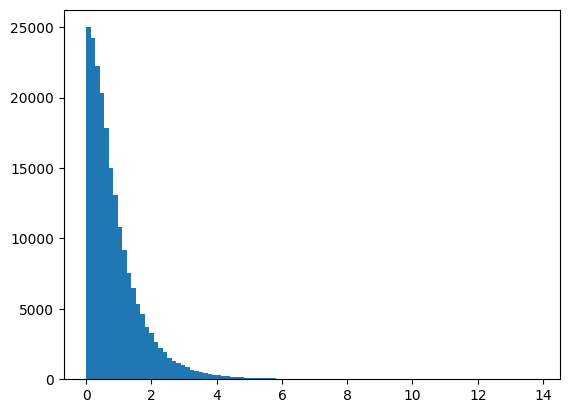

In [57]:
_ = plt.hist(b,bins=100)

In [13]:
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd

def get_detailed_cluster_info(arr, k=3):
    """
    تولید اطلاعات کامل شامل لیبل‌ها و جزئیات هر دسته
    
    Returns:
    tuple: (labels, cluster_info)
    """
    data = np.array(arr).reshape(-1, 1)
    
    # اجرای K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)
    centers = kmeans.cluster_centers_.flatten()
    
    # ایجاد دیتافریم برای نمایش بهتر
    df = pd.DataFrame({
        'value': arr,
        'cluster_label': labels,
        'cluster_center': [centers[label] for label in labels]
    })
    
    # اطلاعات هر دسته
    cluster_info = {}
    for cluster_id in range(k):
        cluster_data = data[labels == cluster_id].flatten()
        cluster_info[cluster_id] = {
            'size': len(cluster_data),
            'center': centers[cluster_id],
            'min': np.min(cluster_data),
            'max': np.max(cluster_data)
        }
    
    return labels, df, cluster_info

# مثال استفاده
if __name__ == "__main__":
    # داده‌های پیچیده‌تر
    complex_data = aaa
    
    # دریافت اطلاعات
    labels, df, cluster_info = get_detailed_cluster_info(complex_data, k=2)
    
    #print("📊 نتایج کامل خوشه‌بندی:")
    #print("=" * 40)
    #print(df.to_string(index=False))
    
    print("\n📋 اطلاعات هر دسته:")
    for cluster_id, info in cluster_info.items():
        print(f"دسته {cluster_id}: {info['size']} عضو، مرکز: {info['center']:.2f}")


📋 اطلاعات هر دسته:
دسته 0: 1224 عضو، مرکز: 0.00
دسته 1: 7290 عضو، مرکز: 0.00


In [14]:
dff1 = dff[(dff[0] == 'پرند') & (dff[1] == 'G11')]

In [15]:
dff1.sort_values(by=[4]).head(100)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43
35771,پرند,G11,38.228000,7.0,878.77734,P,56425,SO,124.407874,37.728000,7.0,878.88110,P,56901,SO,123.441174,35.228000,9.0,879.30194,P,56919,SO,122.367684,34.528000,6.0,880.57930,P,57014,SO,121.964142,32.828000,6.0,881.07380,P,56462,SO,122.253028,31.627998,7.0,881.55410,M,54840,SO,121.992242
35772,پرند,G11,37.728000,7.0,878.88110,P,56901,SO,123.441174,35.228000,9.0,879.30194,P,56919,SO,122.367684,34.528000,6.0,880.57930,P,57014,SO,121.964142,32.828000,6.0,881.07380,P,56462,SO,122.253028,31.627998,7.0,881.55410,M,54840,SO,121.992242,30.528000,8.0,881.79865,M,53121,SO,122.282254
35770,پرند,G11,38.328000,7.0,879.16600,M,56401,SO,125.455512,38.228000,7.0,878.77734,P,56425,SO,124.407874,37.728000,7.0,878.88110,P,56901,SO,123.441174,35.228000,9.0,879.30194,P,56919,SO,122.367684,34.528000,6.0,880.57930,P,57014,SO,121.964142,32.828000,6.0,881.07380,P,56462,SO,122.253028
35773,پرند,G11,35.228000,9.0,879.30194,P,56919,SO,122.367684,34.528000,6.0,880.57930,P,57014,SO,121.964142,32.828000,6.0,881.07380,P,56462,SO,122.253028,31.627998,7.0,881.55410,M,54840,SO,121.992242,30.528000,8.0,881.79865,M,53121,SO,122.282254,29.828000,8.0,882.00110,M,54380,SO,123.272564
35769,پرند,G11,37.828000,8.0,879.44750,M,55839,SO,126.531250,38.328000,7.0,879.16600,M,56401,SO,125.455512,38.228000,7.0,878.77734,P,56425,SO,124.407874,37.728000,7.0,878.88110,P,56901,SO,123.441174,35.228000,9.0,879.30194,P,56919,SO,122.367684,34.528000,6.0,880.57930,P,57014,SO,121.964142
35768,پرند,G11,37.128000,8.0,879.84080,M,54641,SO,127.641834,37.828000,8.0,879.44750,M,55839,SO,126.531250,38.328000,7.0,879.16600,M,56401,SO,125.455512,38.228000,7.0,878.77734,P,56425,SO,124.407874,37.728000,7.0,878.88110,P,56901,SO,123.441174,35.228000,9.0,879.30194,P,56919,SO,122.367684
35774,پرند,G11,34.528000,6.0,880.57930,P,57014,SO,121.964142,32.828000,6.0,881.07380,P,56462,SO,122.253028,31.627998,7.0,881.55410,M,54840,SO,121.992242,30.528000,8.0,881.79865,M,53121,SO,122.282254,29.828000,8.0,882.00110,M,54380,SO,123.272564,29.127998,9.0,882.02490,M,56238,SO,125.679202
35767,پرند,G11,36.427998,9.0,880.58850,M,52180,SO,129.151464,37.128000,8.0,879.84080,M,54641,SO,127.641834,37.828000,8.0,879.44750,M,55839,SO,126.531250,38.328000,7.0,879.16600,M,56401,SO,125.455512,38.228000,7.0,878.77734,P,56425,SO,124.407874,37.728000,7.0,878.88110,P,56901,SO,123.441174
35775,پرند,G11,32.828000,6.0,881.07380,P,56462,SO,122.253028,31.627998,7.0,881.55410,M,54840,SO,121.992242,30.528000,8.0,881.79865,M,53121,SO,122.282254,29.828000,8.0,882.00110,M,54380,SO,123.272564,29.127998,9.0,882.02490,M,56238,SO,125.679202,28.028000,11.0,882.26260,M,56056,SO,127.112396
35766,پرند,G11,35.528000,9.0,881.09070,M,50026,SO,130.118168,36.427998,9.0,880.58850,M,52180,SO,129.151464,37.128000,8.0,879.84080,M,54641,SO,127.641834,37.828000,8.0,879.44750,M,55839,SO,126.531250,38.328000,7.0,879.16600,M,56401,SO,125.455512,38.228000,7.0,878.77734,P,56425,SO,124.407874


In [16]:
csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
csv_write_path = os.path.join(project_root, "data", "processed", "data_for_plot.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')
mask = df["is_good_peak"] == 3
df.loc[mask,'mean_generation'] = df[mask].groupby(['name', 'code'])['generation'].transform('mean')
df.to_csv(csv_write_path)

In [17]:
import pandas as pd

# Sample DataFrame
data = {
    'A': ['a1', 'a1', 'a2', 'a2', 'a3', 'a3'],
    'D': ['x', 'x', 'x', 'y', 'x', 'y'],
    'B': [10.0, 15.0, 10.0, 20.0, 10.0, 25.0]
}
df = pd.DataFrame(data)

# Add column C with group mean of B by A and D
df['C'] = df.groupby(['A', 'D'])['B'].transform('mean')

print(df)
b = df.groupby(['A', 'D'])['B'].mean()

    A  D     B     C
0  a1  x  10.0  12.5
1  a1  x  15.0  12.5
2  a2  x  10.0  10.0
3  a2  y  20.0  20.0
4  a3  x  10.0  10.0
5  a3  y  25.0  25.0
